In [1]:
import tensorflow as tf

# Check available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPUs are available:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPUs detected.")

2025-06-07 06:55:39.809140: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-07 06:55:39.809293: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-07 06:55:39.941344: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPUs are available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from collections import Counter

In [3]:
ds_path = Path('/kaggle/input/cottonweed/CottonWeedID15_500_UM').resolve()

In [4]:
ds_path

PosixPath('/kaggle/input/cottonweed/CottonWeedID15_500_UM')

In [5]:
paths = list(ds_path.glob('*/*'))
classes = [path.parent.stem for path in paths]

In [6]:
Counter(classes)

Counter({'Nutsedge': 450,
         'Sicklepod': 450,
         'Morningglory': 450,
         'Ragweed': 450,
         'PalmerAmaranth': 450,
         'Waterhemp': 450,
         'Crabgrass': 450,
         'Swinecress': 450,
         'Prickly Sida': 450,
         'Carpetweeds': 450,
         'SpottedSpurge': 450,
         'SpurredAnoda': 450,
         'Eclipta': 450,
         'Goosegrass': 450,
         'Purslane': 450})

In [7]:
# # label2id = {'Nutsedge': 0, 'Sicklepod': 1, 'Morningglory': 2, 'Ragweed': 3,
# #             'PalmerAmaranth': 4, 'Waterhemp': 5, 'Crabgrass': 6, 'Swinecress': 7,
# #             'Prickly Sida': 8, 'Carpetweeds': 9, 'SpottedSpurge': 10, 'SpurredAnoda': 11,
# #             'Eclipta': 12, 'Goosegrass': 13, 'Purslane': 14}
# id2label = {label2id[i]:i for i in label2id}
# class_names = [id2label[i] for i in range(len(label2id))]

# print(id2label)
# print(label2id)
# print(class_names)

In [8]:
df = pd.DataFrame({'img':paths, 'class': classes})
df['class'] = df['class'].astype('category')
df['label'] = df['class'].cat.codes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6750 entries, 0 to 6749
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   img     6750 non-null   object  
 1   class   6750 non-null   category
 2   label   6750 non-null   int8    
dtypes: category(1), int8(1), object(1)
memory usage: 66.7+ KB


In [9]:
class_labels = dict(zip(range(15), df['class'].cat.categories))
class_labels

{0: 'Carpetweeds',
 1: 'Crabgrass',
 2: 'Eclipta',
 3: 'Goosegrass',
 4: 'Morningglory',
 5: 'Nutsedge',
 6: 'PalmerAmaranth',
 7: 'Prickly Sida',
 8: 'Purslane',
 9: 'Ragweed',
 10: 'Sicklepod',
 11: 'SpottedSpurge',
 12: 'SpurredAnoda',
 13: 'Swinecress',
 14: 'Waterhemp'}

In [10]:
num_classes = len(class_labels)
num_classes

15

In [11]:
df['img']=df['img'].astype(str)
#df['label']=df['img'].astype(str)

In [12]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.3, shuffle=True, random_state=1230, stratify=df['label'])
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
len(train), len(test)

(4725, 2025)

In [13]:
train.reset_index(inplace=True)
test.reset_index(inplace=True)

In [14]:
train.head()

,index,img,class,label
0,0,/kaggle/input/cottonweed/CottonWeedID15_500_UM...,Purslane,8
1,1,/kaggle/input/cottonweed/CottonWeedID15_500_UM...,Morningglory,4
2,2,/kaggle/input/cottonweed/CottonWeedID15_500_UM...,Carpetweeds,0
3,3,/kaggle/input/cottonweed/CottonWeedID15_500_UM...,Nutsedge,5
4,4,/kaggle/input/cottonweed/CottonWeedID15_500_UM...,Waterhemp,14


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    #rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.1  # Set validation split
)

In [16]:
image_size = (256, 256)  # Change based on your model's requirements
batch_size = 32

In [17]:
# Train Data Generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col='img',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use subset for training
)

Found 4253 validated image filenames belonging to 15 classes.


In [18]:
print("Class indices:", train_generator.class_indices)

Class indices: {'Carpetweeds': 0, 'Crabgrass': 1, 'Eclipta': 2, 'Goosegrass': 3, 'Morningglory': 4, 'Nutsedge': 5, 'PalmerAmaranth': 6, 'Prickly Sida': 7, 'Purslane': 8, 'Ragweed': 9, 'Sicklepod': 10, 'SpottedSpurge': 11, 'SpurredAnoda': 12, 'Swinecress': 13, 'Waterhemp': 14}


In [19]:
# Validation Data Generator
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col='img',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use subset for validation
)

Found 472 validated image filenames belonging to 15 classes.


In [20]:
print("Class indices:", validation_generator.class_indices)

Class indices: {'Carpetweeds': 0, 'Crabgrass': 1, 'Eclipta': 2, 'Goosegrass': 3, 'Morningglory': 4, 'Nutsedge': 5, 'PalmerAmaranth': 6, 'Prickly Sida': 7, 'Purslane': 8, 'Ragweed': 9, 'Sicklepod': 10, 'SpottedSpurge': 11, 'SpurredAnoda': 12, 'Swinecress': 13, 'Waterhemp': 14}


In [21]:
# Create ImageDataGenerator for test (no augmentation)
test_datagen = ImageDataGenerator(#rescale=1./255
)

In [22]:
# Test Data Generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='img',
    y_col='class',  # Assuming test data might still have labels, if not, use None
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',  # Use 'None' if no labels are available
    shuffle=False  # Important for test data to maintain order
)

Found 2025 validated image filenames belonging to 15 classes.


In [23]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large, VGG16,DenseNet121,ResNet50,InceptionV3
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtSmall,EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D,Flatten,Dropout
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras.applications.mobilenet import preprocess_input as mob_preprocess_input
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess_input
from tensorflow.keras.applications.inception_v3 import preprocess_input as inc_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preporcess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobv2_preprocess_input

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, Dense, Multiply, Concatenate, BatchNormalization, Activation,Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Concatenate, Multiply
    
def cbam_spatial_attention(input_feature):
    # Use Lambda layers to wrap tf functions
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_feature)
    # Concatenate along channel axis
    concat = Concatenate(axis=-1)([avg_pool, max_pool])  # (H, W, 2)

    # Apply 7x7 convolution → 1-channel spatial attention map
    attention = Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(concat)  # (H, W, 1)

    # Multiply attention map with input feature map
    output = Multiply()([input_feature, attention])

    return output

In [25]:
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, GlobalMaxPooling2D,
    Reshape, Add, Activation, Multiply, Permute
)
from tensorflow.keras import backend as K

def channel_attention(input_feature, ratio=8):
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    channel = K.int_shape(input_feature)[channel_axis]

    shared_layer_one = Dense(channel // ratio,
                             activation='relu',
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')
    shared_layer_two = Dense(channel,
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1, 1, channel))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    cbam_feature = Add()([avg_pool, max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return Multiply()([input_feature, cbam_feature])

In [26]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetV2B0

# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy('mixed_float16')

# --- ConvBlock Definition ---
class ConvBlock(layers.Layer):
    def __init__(self, filters=256, kernel_size=3, dilation_rate=1, **kwargs):
        super(ConvBlock, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.net = tf.keras.Sequential([
            layers.Conv2D(filters, kernel_size=kernel_size, padding='same', dilation_rate=dilation_rate, use_bias=False,
                          kernel_initializer='he_normal'),
            layers.BatchNormalization(),
            layers.ReLU()
        ])

    def call(self, X):
        return self.net(X)

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "dilation_rate": self.dilation_rate,
        }

# --- Atrous Spatial Pyramid Pooling (ASPP) ---

#@tf.function
def AtrousSpatialPyramidPooling(X):
    B, H, W, C = X.shape

    # Image Pooling
    # image_pool = layers.AveragePooling2D(pool_size=(H, W))(X)
    # image_pool = ConvBlock(kernel_size=1)(image_pool)
    # image_pool = layers.UpSampling2D(size=(H // image_pool.shape[1], W // image_pool.shape[2]))(image_pool)

    image_pool = layers.GlobalAveragePooling2D()(X)
    image_pool = layers.Reshape((1, 1, C))(image_pool)
    image_pool = ConvBlock(kernel_size=1)(image_pool)
    image_pool = layers.UpSampling2D(size=(H, W), interpolation='bilinear')(image_pool)
    # Atrous Operations using dilation
    conv_1 = ConvBlock(kernel_size=1, dilation_rate=1)(X)
    conv_6 = ConvBlock(kernel_size=3, dilation_rate=6)(X)
    conv_12 = ConvBlock(kernel_size=3, dilation_rate=12)(X)
    conv_18 = ConvBlock(kernel_size=3, dilation_rate=18)(X)

    # Combine All
    combined = layers.Concatenate()([image_pool,conv_1, conv_6, conv_12, conv_18])
    processed = ConvBlock(kernel_size=1)(combined)

    return processed

In [27]:
base_model = keras.applications.EfficientNetV2B0(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=image_size + (3,),
    include_top=False) 
base_model.trainable = True

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
import tensorflow as tf
import math

class ECALayer(tf.keras.layers.Layer):
    def __init__(self, gamma=2, b=1, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.gamma = gamma
        self.b = b

    def build(self, input_shape):
        channels = input_shape[-1]
        t = int(abs((math.log2(channels) / self.gamma) + self.b))
        self.k_size = t if t % 2 == 1 else t + 1
        self.conv1d = tf.keras.layers.Conv1D(
            filters=1,
            kernel_size=self.k_size,
            padding='same',
            use_bias=False
        )

    def call(self, x):
        # x: [B, H, W, C]
        squeeze = tf.reduce_mean(x, axis=[1, 2], keepdims=True)  # [B, 1, 1, C]
        squeeze = tf.transpose(squeeze, [0, 3, 1, 2])            # [B, C, 1, 1]
        squeeze = tf.squeeze(squeeze, axis=[2, 3])               # [B, C]
        squeeze = tf.expand_dims(squeeze, axis=-1)              # [B, C, 1]
        attn = self.conv1d(squeeze)                              # [B, C, 1]
        attn = tf.nn.sigmoid(attn)                               # [B, C, 1]
        attn = tf.reshape(attn, [-1, 1, 1, x.shape[-1]])         # [B, 1, 1, C]
        return x * attn

In [29]:
def cbam_block(cbam_feature, ratio=8):
    """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
    As described in https://arxiv.org/abs/1807.06521.
    """

    #cbam_feature = channel_attention(cbam_feature, ratio)
    cbam_feature=ECALayer()(cbam_feature)
    cbam_feature = cbam_spatial_attention(cbam_feature)

    return cbam_feature

In [30]:
def build_model(base_model, num_classes):
    inputs = Input(shape=image_size + (3,))
    x = base_model(inputs, training=False)
    original_features = x

    # CBAM attention modules
    #cbam_channel = channel_attention(x)
    eca=ECALayer()(x)
    cbam = cbam_spatial_attention(x)
    result1 = Add()([eca, cbam])
    result2 = cbam_block(x, ratio=8)
    cbam_feature = Add()([result1, result2])

    # Gated feature fusion
    #x = gated_fusion(cbam_feature, original_features)
    x = Concatenate()([cbam_feature, original_features])
    # Classification head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.1)(x)
    #x=Dense(128, activation='relu')(x)
    #x = BatchNormalization()(x)
    #x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=inputs, outputs=output)
    return model

In [31]:
from tensorflow.keras import backend as K
from tensorflow.keras.layers import GlobalMaxPooling2D,Add,Activation,Multiply
model = build_model(base_model,num_classes)

In [32]:

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 8, 8,      │  5,919,312 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 8, 8, 1)   │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 8, 8, 1)   │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eca_layer_1         │ (None, 8, 8,      │          7 │ efficientnetv2-b… │
│ (ECALayer)          │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 8, 8, 1)   │          0 │ eca_layer_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 8, 8, 1)   │          0 │ eca_layer_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 8, 8, 2)   │          0 │ lambda_2[0][0],   │
│ (Concatenate)       │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eca_layer           │ (None, 8, 8,      │          7 │ efficientnetv2-b… │
│ (ECALayer)          │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 8, 8,      │          0 │ efficientnetv2-b… │
│                     │ 1280)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 1)   │         99 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 8,      │          0 │ eca_layer[0][0],  │
│                     │ 1280)             │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 8, 8,      │          0 │ eca_layer_1[0][0… │
│ (Multiply)          │ 1280)             │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 8,      │          0 │ add[0][0],        │
│                     │ 1280)             │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8,      │          0 │ add_1[0][0],      │
│ (Concatenate)       │ 2560)             │            │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2560)      │          0 │ concatenate_2[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2560)      │          0 │ global_average_p

 Total params: 5,957,939 (22.73 MB)

 Trainable params: 5,897,331 (22.50 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [33]:
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
# Constant for epochs
EPOCHS = 50

pat_es = 5
early_stopping = EarlyStopping(monitor='val_loss', patience=pat_es, verbose=1, restore_best_weights=True)
reduce_lr =ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=3, verbose=1, min_lr=1e-6)

model.compile(loss='categorical_crossentropy',
          optimizer= AdamW(learning_rate=2e-4,  weight_decay=5e-2),
          metrics=['accuracy'])

In [34]:
%%time
%%time
# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr],
    )

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  1/133 ━━━━━━━━━━━━━━━━━━━━ 4:04:46 111s/step - accuracy: 0.0312 - loss: 2.7747

I0000 00:00:1749279478.646727      67 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1749279478.751824      67 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.4989 - loss: 1.7135

W0000 00:00:1749279613.261651      69 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


133/133 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.5005 - loss: 1.7083 - val_accuracy: 0.9301 - val_loss: 0.2247 - learning_rate: 2.0000e-04
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 458ms/step - accuracy: 0.9394 - loss: 0.2226 - val_accuracy: 0.9725 - val_loss: 0.1068 - learning_rate: 2.0000e-04
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 63s 448ms/step - accuracy: 0.9692 - loss: 0.1035 - val_accuracy: 0.9682 - val_loss: 0.1002 - learning_rate: 2.0000e-04
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 63s 448ms/step - accuracy: 0.9699 - loss: 0.0950 - val_accuracy: 0.9767 - val_loss: 0.0730 - learning_rate: 2.0000e-04
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 455ms/step - accuracy: 0.9831 - loss: 0.0513 - val_accuracy: 0.9873 - val_loss: 0.0635 - learning_rate: 2.0000e-04
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 63s 452ms/step - accuracy: 0.9913 - loss: 0.0364 - val_accuracy: 0.9894 - val_loss: 0.0405 - learning_rate: 2.0000e-04
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 62s 446ms/step - ac

In [35]:
# Define your folder to save results
import os
save_folder = model.name
os.makedirs(save_folder, exist_ok=True)

In [36]:
filename= model.name+'.h5'
model_weight= os.path.join(save_folder, filename)
model_weight

'functional/functional.h5'

In [37]:
print("Saving the Model")
model.save(model_weight)

Saving the Model


In [38]:
#image visualization
import matplotlib.pyplot as plt
def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()
    plt.savefig(os.path.join(save_folder, 'training_chart.png'))
    plt.show()

Total Epochs: range(0, 15)


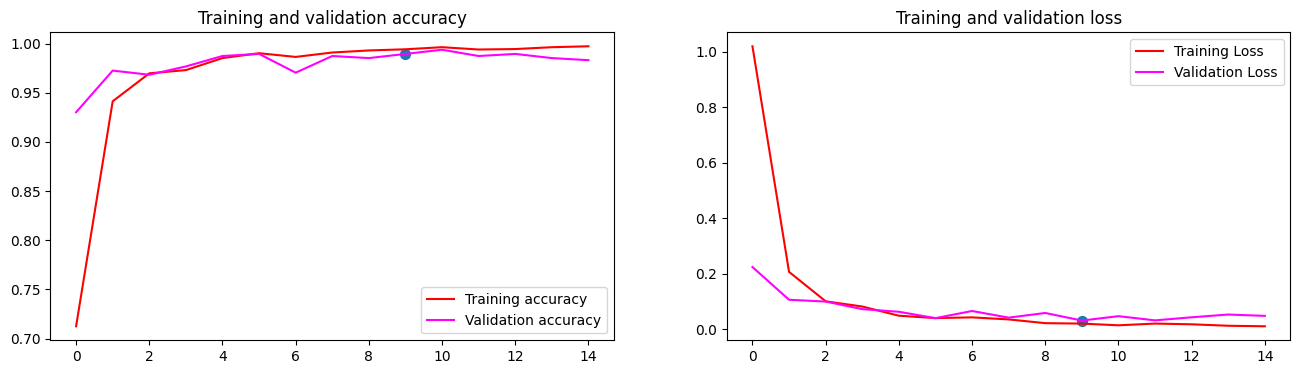

In [39]:
# Plot training results
plot_loss_acc(history1.history)

In [40]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [41]:
predictions=model.predict(test_generator)

 3/64 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step

W0000 00:00:1749280512.935890      67 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 304ms/step


In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)
# Get true labels from the test generator
true_labels = test_generator.classes
# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[134   0   0   0   1   0   0   0   0   0   0   0   0   0   0]
 [  0 134   0   0   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0 135   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   1   0 134   0   0   0   0   0   0   0   0   0   0   0]
 [  1   0   0   0 134   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 135   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   2   0 128   0   2   1   0   1   0   0   1]
 [  0   0   0   0   1   0   1 129   0   0   0   0   0   0   4]
 [  1   1   0   0   0   0   0   0 133   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 135   0   0   0   0   0]
 [  0   0   0   1   0   0   1   0   0   0 133   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   0   0 134   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 135   0   0]
 [  0   0   0   0   0   0   0   0   0   1   0   0   0 134   0]
 [  0   0   2   0   0   0   2   0   0   0   0   0   0   0 131]]


In [43]:
# def eval_model(model, data_gen, use_rand_guess=False):
#     print("model.evaluate")
#     #model.evaluate(data_gen)

#     print("model.predict")
#     actual_labels = []
#     pred_prob = []
#     for batch in tqdm(data_gen):
#         actual_labels.extend([np.argmax(z) for z in batch[1]])
#         pred_prob.extend(list(model(batch[0], training=False)))

#     return actual_labels, pred_prob

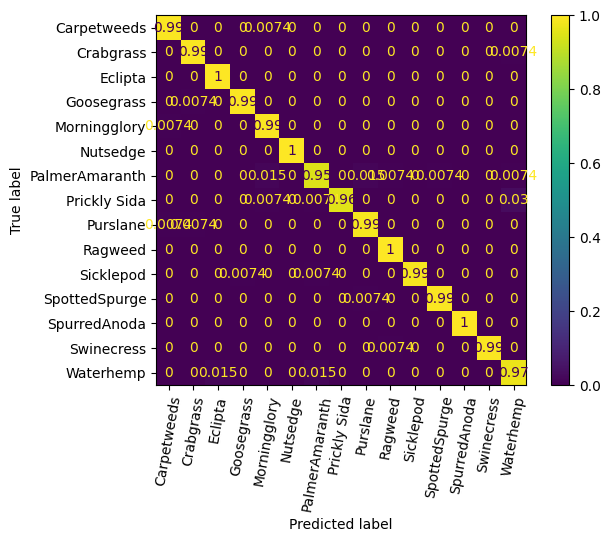

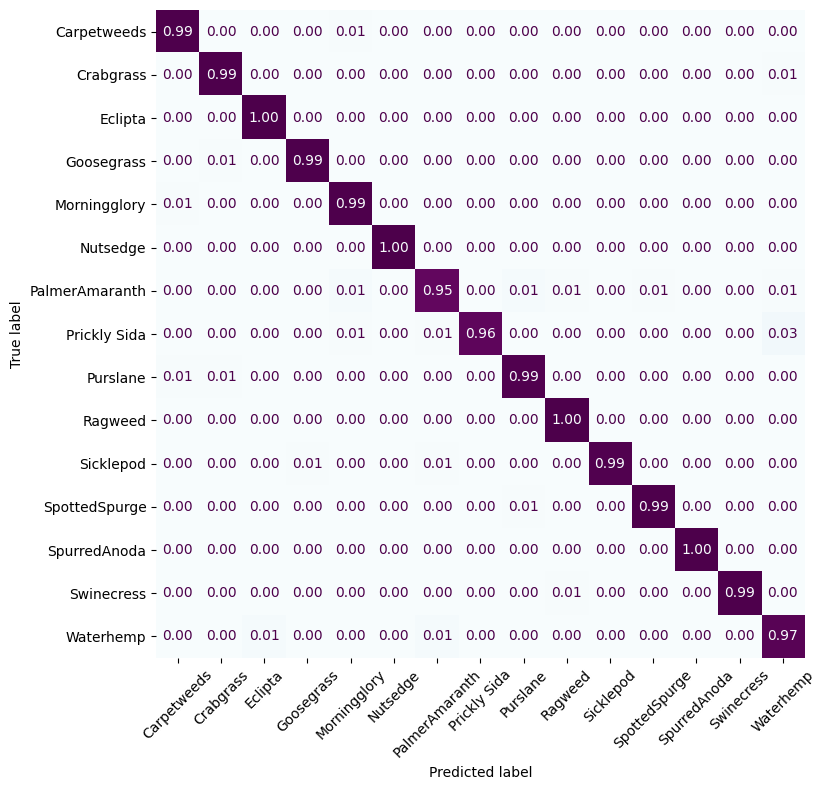

In [44]:
cmd = ConfusionMatrixDisplay.from_predictions(
        true_labels, predicted_classes,
        display_labels=list(test_generator.class_indices.keys()),
        xticks_rotation=80, #'vertical',
        normalize='true'
        # ax = ax
    )
    # fig, ax = plt.subplots(figsize=(25,5))
    # cmd.plot(ax=ax)
fig, ax = plt.subplots(figsize=(10, 8))
           # Remove axis spines (frame)
for spine in ax.spines.values():
        spine.set_visible(False)
cmd.plot(ax=ax, cmap='BuPu', xticks_rotation=45,  values_format='.2f', colorbar=False)
plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'confusion-mat.png'),dpi=600)
plt.show()

In [45]:
display_labels=list(test_generator.class_indices.keys())
class_report=classification_report(true_labels, predicted_classes,digits=5, target_names=display_labels)
print(class_report)
with open(os.path.join(save_folder, 'classification_report.txt'), 'w') as f:
    f.write(classification_report(true_labels, predicted_classes))

                precision    recall  f1-score   support

   Carpetweeds    0.98529   0.99259   0.98893       135
     Crabgrass    0.98529   0.99259   0.98893       135
       Eclipta    0.98540   1.00000   0.99265       135
    Goosegrass    0.99259   0.99259   0.99259       135
  Morningglory    0.97101   0.99259   0.98168       135
      Nutsedge    1.00000   1.00000   1.00000       135
PalmerAmaranth    0.96970   0.94815   0.95880       135
  Prickly Sida    1.00000   0.95556   0.97727       135
      Purslane    0.97794   0.98519   0.98155       135
       Ragweed    0.98540   1.00000   0.99265       135
     Sicklepod    1.00000   0.98519   0.99254       135
 SpottedSpurge    0.99259   0.99259   0.99259       135
  SpurredAnoda    1.00000   1.00000   1.00000       135
    Swinecress    1.00000   0.99259   0.99628       135
     Waterhemp    0.95620   0.97037   0.96324       135

      accuracy                        0.98667      2025
     macro avg    0.98676   0.98667   0.98665 